<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/Erb%2C%20C.%20B.%2C%20Harvey%2C%20C.%20R.%2C%20%26%20Viskanta%2C%20T.%20E.%20(2011).%20International%20diversification%20works%20(eventually)/International_Diversification_for_the_Long_run.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Use the "F-F_International_Countries" Data, Download the folder extract the contents, then when you open the folder select all the files to up load them faster.

In [61]:
#from google.colab import files
#uploaded = files.upload()

In [62]:
import pandas as pd
import os

files = [f for f in os.listdir() if f.endswith('.Dat')]

for file in files:
    country = file.replace('.Dat', '')

    df = pd.read_csv(
        file,
        sep=r'\s+',          # ✅ replaces deprecated delim_whitespace
        skiprows=10,
        header=None,
        engine='python',     # ✅ handles irregular rows
        on_bad_lines='skip'  # ✅ skips broken rows
    )

    # keep only rows where first column looks like a date
    df = df[df[0].astype(str).str.match(r'^\d{6}$')]

    # clean
    df.rename(columns={0: 'Date'}, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y%m')
    df.set_index('Date', inplace=True)

    # Ensure all data columns (excluding the index) are numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # create variable
    globals()[country] = df

In [63]:
# List of all 21 countries / DataFrame variables
countries = [
    "Austrlia", "Austria", "Belgium", "Canada", "Denmark", "Finland",
    "France", "Germany", "HongKong", "Ireland", "Italy", "Japan",
    "Malaysia", "Nethrlnd", "NewZland", "Norway", "Singapor",
    "Spain", "Sweden", "Swtzrlnd", "UK"
]


countries_dfs = [globals()[country] for country in countries]

# Example: access the first row of the first country (Austrlia)
countries_dfs[0].head(1)

,1,2,3,4,5,6,7,8,9,10
Date,,,,,,,,,,
1975-07-01,-3.94,-5.5,-3.93,-5.15,-3.76,-1.51,-4.56,-5.7,-3.53,13.63


In [64]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║   "International Diversification Works (Eventually)"                 ║
# ║    Asness, Israelov & Liew (FAJ 2011) — Full Colab Replication      ║
# ║    Data: Fama-French 21-country decile portfolios                    ║
# ╚══════════════════════════════════════════════════════════════════════╝
#
# PAPER THESIS:
#   Short-term global correlations rise during crashes → diversification
#   seems to "fail". But over LONG horizons (3–10 years), economic growth
#   dominates panic-driven co-movement, and the globally diversified
#   equal-weighted portfolio dramatically outperforms any single country.
#
# HOW TO RUN: Execute blocks 1 → 10 in order.
# Each block is self-contained and prints progress so you know it worked.


# ══════════════════════════════════════════════════════════════════════
# BLOCK 1 — Install dependencies
# ══════════════════════════════════════════════════════════════════════
# linearmodels is the only non-standard library needed.

!pip install linearmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os
from scipy import stats
from linearmodels.panel import PanelOLS
import statsmodels.api as sm
from google.colab import files

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 11, "axes.labelsize": 10})

print("✓ Block 1 complete — all packages loaded")



# ══════════════════════════════════════════════════════════════════════
# BLOCK 3 — Parse .Dat files into DataFrames
# ══════════════════════════════════════════════════════════════════════
#
# Each file has:
#   • 10 header/description rows  → skip
#   • Rows like:  YYYYMM  r1  r2  r3 … r10   (percentage returns)
#   • Sentinel -99.99 means "no data" → treated as NaN
#
# Output: `countries` (list of str), `countries_dfs` (list of DataFrames)
#   Each DataFrame: Date (datetime) | 1 | 2 | … | 10  (% returns)

SENTINEL = -99.99

def load_fama_french_dats(filenames):
    countries, dfs = [], []
    for fname in sorted(filenames):
        if not fname.endswith(".Dat"):
            continue
        country = fname.replace(".Dat", "")
        df = pd.read_csv(fname, sep=r"\s+", skiprows=10, header=None,
                         engine="python", on_bad_lines="skip")
        # keep only rows where col 0 is a 6-digit date (YYYYMM)
        df = df[df[0].astype(str).str.match(r"^\d{6}$")].copy()
        if df.empty:
            print(f"  ⚠  {fname}: no valid rows — skipped"); continue

        df.rename(columns={0: "Date"}, inplace=True)
        df["Date"] = pd.to_datetime(df["Date"], format="%Y%m")
        data_cols = [c for c in df.columns if c != "Date"]
        df.rename(columns={old: i+1 for i, old in enumerate(data_cols)}, inplace=True)
        for col in df.columns:
            if col != "Date":
                df[col] = pd.to_numeric(df[col], errors="coerce")
        df.replace(SENTINEL, np.nan, inplace=True)
        df = df.reset_index(drop=True)
        countries.append(country)
        dfs.append(df)
        port_count = sum(1 for c in df.columns if c != "Date")
        print(f"  ✓  {country:22s}  {len(df):>4} rows  |  {port_count} portfolios")

    print(f"\n✓ Block 3 complete — {len(countries)} countries loaded")
    return countries, dfs

countries, countries_dfs = load_fama_french_dats(uploaded.keys())


# ══════════════════════════════════════════════════════════════════════
# BLOCK 4 — Interpolate short gaps (≤ 6 consecutive missing months)
# ══════════════════════════════════════════════════════════════════════
#
# The Fama-French files use -99.99 for missing observations (already
# converted to NaN in Block 3).  Short gaps are filled via time-based
# linear interpolation; gaps longer than MAX_GAP stay NaN.
#
# Why interpolate?  Avoids look-ahead bias from forward-fill and is
# more defensible than dropping entire country-months.

MAX_GAP = 6   # months

def _nan_run_lengths(s: pd.Series) -> pd.Series:
    """Return, for each NaN position, the length of its consecutive run."""
    # Rewritten to avoid the deprecated positional __getitem__ on Series
    is_na   = s.isna().astype(int)
    grp_ids = (is_na.diff().ne(0)).cumsum()          # group id per run
    grp_ids = grp_ids.where(is_na == 1)              # only NaN runs
    sizes   = grp_ids.map(grp_ids.value_counts())    # broadcast run length
    return sizes.fillna(0).astype(int)

def interpolate_returns(dfs, countries, max_gap=MAX_GAP):
    cleaned = []
    for df, country in zip(dfs, countries):
        d         = df.copy()
        port_cols = [c for c in d.columns if c != "Date"]
        d         = d.sort_values("Date").reset_index(drop=True)
        d_idx     = d.set_index("Date")

        for col in port_cols:
            s        = d_idx[col].astype(float)
            run_len  = _nan_run_lengths(s)
            long_gap = (run_len > max_gap)
            s2       = s.copy()
            s2[long_gap] = np.nan                     # freeze long gaps
            s_interp = s2.interpolate(method="time", limit=max_gap,
                                      limit_direction="both")
            s_interp[long_gap] = np.nan               # restore long gaps
            d_idx[col] = s_interp

        d_clean           = d_idx.reset_index()
        d_clean["country"] = country
        cleaned.append(d_clean)

    print(f"✓ Block 4 complete — interpolation done (max_gap={max_gap} months)")
    return cleaned

cleaned_dfs = interpolate_returns(countries_dfs, countries)


# ══════════════════════════════════════════════════════════════════════
# BLOCK 5 — Build the equal-weighted LOCAL and GLOBAL return series
# ══════════════════════════════════════════════════════════════════════
#
# PAPER METHODOLOGY (Section "Data"):
#   Local portfolio  = equal-weighted average of the 10 decile portfolios
#                      for that country (proxy for the domestic market).
#   Global portfolio = equal-weighted average of ALL countries' local
#                      returns in that month (no currency hedging).
#
# Returns are kept in % here; we convert to decimals only for compounding.
#
# Additional panel variables (used in the regression block):
#   sd_ret  — cross-portfolio std dev (dispersion proxy)
#   n_port  — number of active portfolios
#   HHI     — Herfindahl index of |return| weights
#             (lower HHI = more evenly spread = more "within-country diversified")

def compute_country_metrics(df, port_cols):
    """Per-country-month: ew_ret (%), sd_ret, n_port, HHI."""
    long = df.melt(id_vars=["country","Date"], value_vars=port_cols,
                   var_name="portfolio", value_name="ret_pct")
    agg = (long.groupby(["country","Date"])
               .agg(n_port  =("ret_pct","count"),
                    ew_ret  =("ret_pct","mean"),   # equal-weighted local return (%)
                    sd_ret  =("ret_pct","std"))
               .reset_index())
    # HHI on absolute returns — avoid the include_groups DeprecationWarning
    def _hhi(grp):
        vals = grp["ret_pct"].abs().dropna().values
        if vals.size == 0 or vals.sum() == 0: return np.nan
        w = vals / vals.sum()
        return float((w**2).sum())
    hhi_s  = long.groupby(["country","Date"], group_keys=False).apply(_hhi)
    hhi_df = hhi_s.reset_index(name="HHI")
    return agg.merge(hhi_df, on=["country","Date"], how="left"), long

agg_list, long_list = [], []
for df, country in zip(cleaned_dfs, countries):
    port_cols = [c for c in df.columns if c not in ("Date","country")]
    agg, long = compute_country_metrics(df, port_cols)
    agg_list.append(agg)
    long_list.append(long)

country_panel = pd.concat(agg_list,  ignore_index=True)
long_panel    = pd.concat(long_list, ignore_index=True)

# ── Global equal-weighted portfolio (across all countries) ──────────────
global_ew = (country_panel
             .groupby("Date")["ew_ret"]
             .mean()
             .rename("global_ew_ret")
             .reset_index())

# Merge onto panel so each row knows both local and global returns
country_panel = country_panel.merge(global_ew, on="Date", how="left")

print(f"✓ Block 5 complete — panel: {len(country_panel):,} country-month rows")
print(f"   Date range : {country_panel['Date'].min().date()} → "
      f"{country_panel['Date'].max().date()}")
print(f"   Countries  : {sorted(country_panel['country'].unique())}")
print(country_panel[["country","Date","ew_ret","global_ew_ret","sd_ret","HHI"]].head(8))


# ══════════════════════════════════════════════════════════════════════
# BLOCK 6 — Rolling multi-horizon worst-case analysis
# ══════════════════════════════════════════════════════════════════════
#
# CORE PAPER RESULT (Figures 1–3):
#   For each country and each horizon h (1 to 120 months):
#     1. Compute overlapping h-month compound returns for local portfolio.
#     2. Find the WORST h-month window for the local portfolio.
#     3. Record the global portfolio return during that SAME window.
#     4. Separately find the WORST h-month window for the global portfolio.
#
#   Then average across countries. The "gap" between local worst-case and
#   global worst-case WIDENS as h grows → diversification pays eventually.
#
# MATH:
#   Compound return over window [t, t+h):
#     R_h = ∏_{k=t}^{t+h-1} (1 + r_k/100) - 1
#
#   Worst local window index: t* = argmin_t  R_local_h(t)
#   Global return in that window: R_global_h(t*)

HORIZONS = [1, 3, 6, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120]

def compound_returns(series_pct: pd.Series, h: int) -> pd.Series:
    """Overlapping h-month compound returns from a % series."""
    r = series_pct.values / 100.0
    n = len(r)
    if n < h:
        return pd.Series(dtype=float)
    out = np.empty(n - h + 1)
    for i in range(n - h + 1):
        out[i] = np.prod(1 + r[i:i+h]) - 1
    return pd.Series(out)

results_by_country = {}   # country → {h → dict of metrics}

for country in countries:
    cp   = country_panel[country_panel["country"] == country].sort_values("Date")
    loc  = cp["ew_ret"].values
    glob = cp["global_ew_ret"].values

    res = {}
    for h in HORIZONS:
        loc_h  = compound_returns(pd.Series(loc),  h)
        glob_h = compound_returns(pd.Series(glob), h)
        if len(loc_h) == 0:
            continue

        worst_local_idx = int(loc_h.idxmin())
        res[h] = {
            "worst_local"       : float(loc_h.min()),          # worst local h-month return
            "global_at_worst_local": float(glob_h.iloc[worst_local_idx]),  # global in same window
            "worst_global"      : float(glob_h.min()),         # global own worst window
            "cvar1_local"       : float(loc_h.quantile(0.01)),
            "cvar5_local"       : float(loc_h.quantile(0.05)),
            "cvar1_global"      : float(glob_h.quantile(0.01)),
            "cvar5_global"      : float(glob_h.quantile(0.05)),
            "skew_local"        : float(stats.skew(loc_h.dropna())),
            "skew_global"       : float(stats.skew(glob_h.dropna())),
        }
    results_by_country[country] = res

# Cross-country averages at each horizon
def avg_across(metric):
    return {h: np.nanmean([results_by_country[c][h][metric]
                           for c in countries if h in results_by_country[c]])
            for h in HORIZONS}

avg_worst_local           = avg_across("worst_local")
avg_global_at_worst_local = avg_across("global_at_worst_local")
avg_worst_global          = avg_across("worst_global")
avg_cvar1_local           = avg_across("cvar1_local")
avg_cvar1_global          = avg_across("cvar1_global")
avg_cvar5_local           = avg_across("cvar5_local")
avg_cvar5_global          = avg_across("cvar5_global")
avg_skew_local            = avg_across("skew_local")
avg_skew_global           = avg_across("skew_global")

print("✓ Block 6 complete — worst-case analysis across all horizons")
print(f"\n{'Horizon':>8} | {'Worst Local':>12} | {'Global@WorstLocal':>17} | {'Worst Global':>13}")
print("-"*60)
for h in HORIZONS:
    print(f"{h:>8}m | {avg_worst_local[h]*100:>11.1f}% | "
          f"{avg_global_at_worst_local[h]*100:>16.1f}% | "
          f"{avg_worst_global[h]*100:>12.1f}%")


✓ Block 1 complete — all packages loaded
  ✓  Austria                 1818 rows  |  10 portfolios
  ✓  Austrlia                2442 rows  |  10 portfolios
  ✓  Belgium                 2442 rows  |  10 portfolios
  ✓  Canada                  2346 rows  |  10 portfolios
  ✓  Denmark                 1770 rows  |  10 portfolios
  ✓  Finland                 1818 rows  |  10 portfolios
  ✓  France                  2442 rows  |  10 portfolios
  ✓  Germany                 2442 rows  |  10 portfolios
  ✓  HongKong                2442 rows  |  10 portfolios
  ✓  Ireland                 1674 rows  |  10 portfolios
  ✓  Italy                   2442 rows  |  10 portfolios
  ✓  Japan                   2442 rows  |  10 portfolios
  ✓  Malaysia                 370 rows  |  10 portfolios
  ✓  Nethrlnd                2442 rows  |  10 portfolios
  ✓  NewZland                1818 rows  |  10 portfolios
  ✓  Norway                  2178 rows  |  10 portfolios
  ✓  Singapor                2442 rows  |  10 p

This table shows the worst-case investment losses over different time horizons for local markets, the global market at the time of each local worst case, and the absolute worst global outcome. Short-term local losses are very large (e.g., -26.3% in 1 month), and global losses at the same time are smaller, reflecting some diversification. As the horizon lengthens, local worst-case losses become less extreme, and global aggregation greatly reduces risk, with the 120-month global worst-case even turning positive (+36.9%). Overall, it shows that short-term shocks are severe locally, but over longer periods, diversification and time dramatically reduce downside risk.


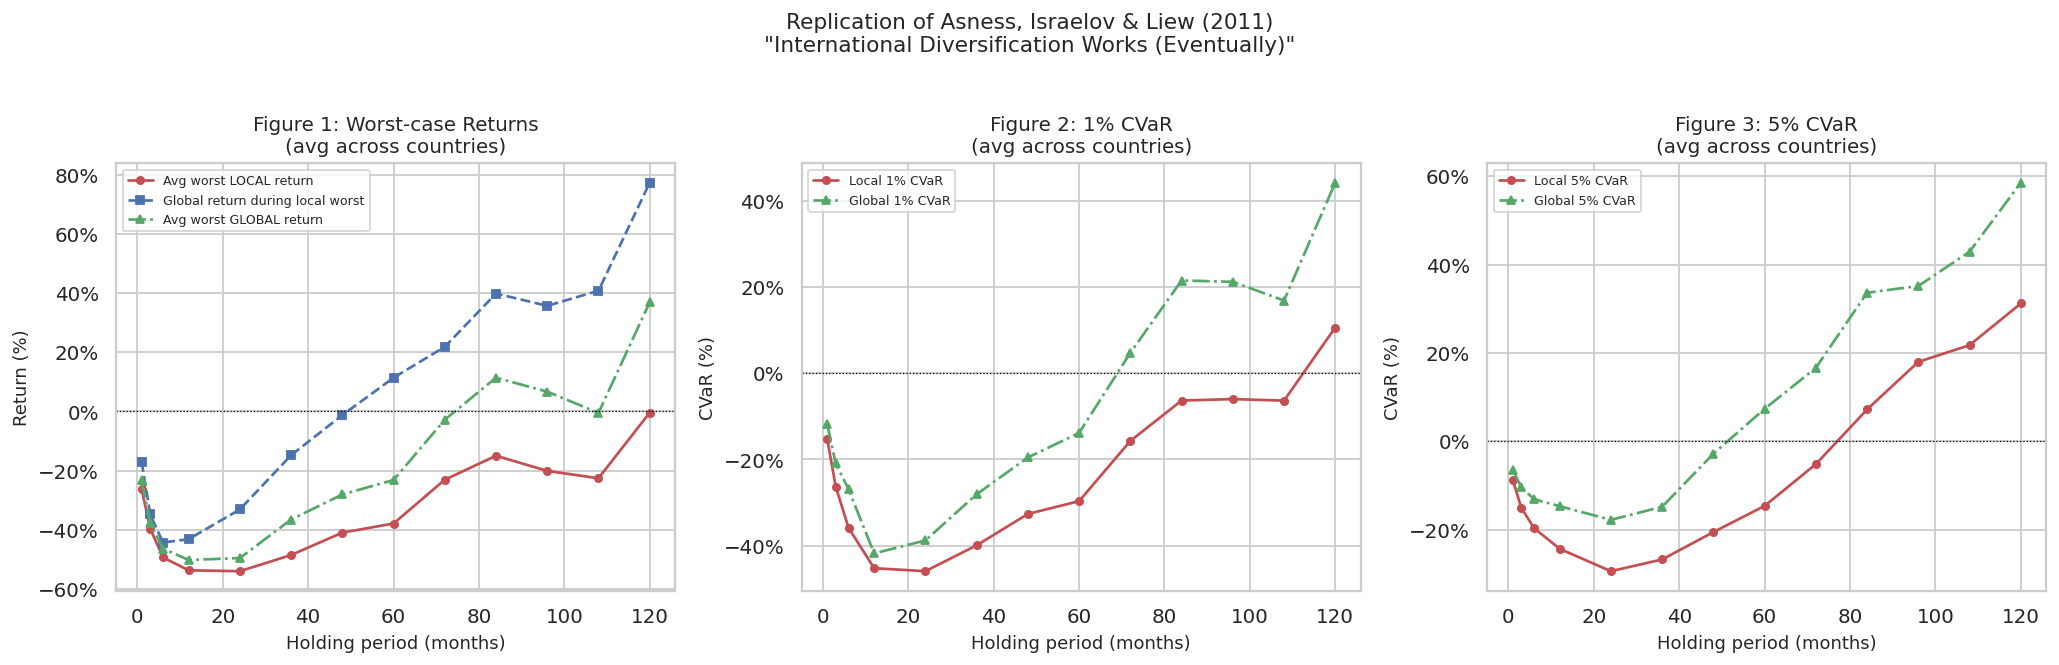

✓ Block 7 complete — Figures 1–3 saved


In [65]:


# ══════════════════════════════════════════════════════════════════════
# BLOCK 7 — Reproduce Figures 1, 2, 3 from the paper
# ══════════════════════════════════════════════════════════════════════
#
# FIGURE 1: Worst-case returns (local worst, global concurrent, global own worst)
# FIGURE 2: 1% CVaR
# FIGURE 3: 5% CVaR
#
# KEY INSIGHT: The gap between local worst-case and global worst-case
# widens as the horizon grows.  At 1 month the three lines are bunched;
# by 60–120 months the global worst-case is dramatically better.

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle(
    'Replication of Asness, Israelov & Liew (2011)\n'
    '"International Diversification Works (Eventually)"',
    fontsize=12, y=1.02
)

h_vals = list(HORIZONS)
pct    = lambda d: [d[h]*100 for h in h_vals]

# ── Figure 1: Worst returns ──────────────────────────────────────────
ax = axes[0]
ax.plot(h_vals, pct(avg_worst_local),           "r-o",  ms=4, label="Avg worst LOCAL return")
ax.plot(h_vals, pct(avg_global_at_worst_local), "b--s", ms=4, label="Global return during local worst")
ax.plot(h_vals, pct(avg_worst_global),          "g-.^", ms=4, label="Avg worst GLOBAL return")
ax.axhline(0, color="black", lw=0.7, ls=":")
ax.set_title("Figure 1: Worst-case Returns\n(avg across countries)")
ax.set_xlabel("Holding period (months)")
ax.set_ylabel("Return (%)")
ax.legend(fontsize=7)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# ── Figure 2: 1% CVaR ───────────────────────────────────────────────
ax = axes[1]
ax.plot(h_vals, pct(avg_cvar1_local),  "r-o",  ms=4, label="Local 1% CVaR")
ax.plot(h_vals, pct(avg_cvar1_global), "g-.^", ms=4, label="Global 1% CVaR")
ax.axhline(0, color="black", lw=0.7, ls=":")
ax.set_title("Figure 2: 1% CVaR\n(avg across countries)")
ax.set_xlabel("Holding period (months)")
ax.set_ylabel("CVaR (%)")
ax.legend(fontsize=7)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# ── Figure 3: 5% CVaR ───────────────────────────────────────────────
ax = axes[2]
ax.plot(h_vals, pct(avg_cvar5_local),  "r-o",  ms=4, label="Local 5% CVaR")
ax.plot(h_vals, pct(avg_cvar5_global), "g-.^", ms=4, label="Global 5% CVaR")
ax.axhline(0, color="black", lw=0.7, ls=":")
ax.set_title("Figure 3: 5% CVaR\n(avg across countries)")
ax.set_xlabel("Holding period (months)")
ax.set_ylabel("CVaR (%)")
ax.legend(fontsize=7)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig("fig1_2_3_worst_case.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Block 7 complete — Figures 1–3 saved")


These graphs illustrate how international diversification reduces investment risk over time. The first graph shows that worst-case returns in local markets are much more severe in the short term, while global markets experience smaller losses during those local downturns. Over longer holding periods, the worst global returns improve significantly, even turning positive, highlighting how diversification smooths outcomes. The second and third graphs display the 1% and 5% Conditional Value-at-Risk (CVaR), measures of extreme downside risk. Both show that local markets face greater losses initially, but global diversification combined with longer holding periods greatly reduces this risk. Overall, the graphs demonstrate that although local markets can be highly volatile in the short run, spreading investments internationally and holding them longer markedly lowers the chance of extreme losses.

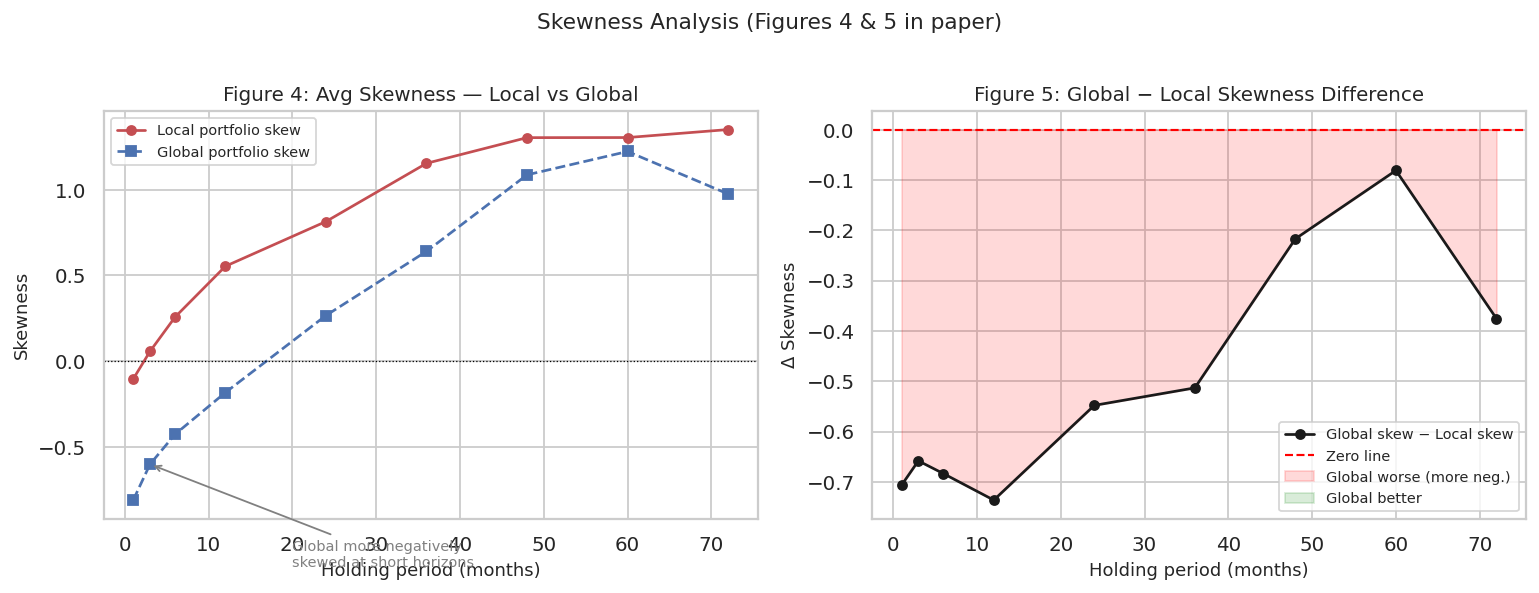

✓ Block 8 complete — skewness figures saved


In [66]:

# ══════════════════════════════════════════════════════════════════════
# BLOCK 8 — Skewness analysis (Figures 4 & 5)
# ══════════════════════════════════════════════════════════════════════
#
# PAPER (Figures 4–5):
#   At short horizons, GLOBAL portfolios are MORE negatively skewed
#   than local (markets crash together → fat left tail).
#   But as horizon grows past ~3.5 years, the difference disappears.
#   Beyond 5 years, even the point estimates converge.
#
# MATH:
#   Skewness = E[(r - μ)^3] / σ^3   (Fisher/Pearson)
#   We use scipy.stats.skew on the overlapping rolling compound return
#   distributions computed in Block 6.

SHORT_HORIZONS = [h for h in HORIZONS if h <= 72]   # up to 6 years

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Skewness Analysis (Figures 4 & 5 in paper)", fontsize=12, y=1.01)

# ── Figure 4: Absolute skewness of local vs global ──────────────────
ax = axes[0]
ax.plot(SHORT_HORIZONS, [avg_skew_local[h]  for h in SHORT_HORIZONS],
        "r-o", ms=5, label="Local portfolio skew")
ax.plot(SHORT_HORIZONS, [avg_skew_global[h] for h in SHORT_HORIZONS],
        "b--s", ms=5, label="Global portfolio skew")
ax.axhline(0, color="black", lw=0.7, ls=":")
ax.set_title("Figure 4: Avg Skewness — Local vs Global")
ax.set_xlabel("Holding period (months)")
ax.set_ylabel("Skewness")
ax.legend(fontsize=8)
ax.annotate("Global more negatively\nskewed at short horizons",
            xy=(3, avg_skew_global[3]), xytext=(20, -1.2),
            arrowprops=dict(arrowstyle="->", color="gray"), fontsize=8, color="gray")

# ── Figure 5: Difference (global skew - local skew) ─────────────────
ax = axes[1]
diff_skew = {h: avg_skew_global[h] - avg_skew_local[h] for h in SHORT_HORIZONS}
ax.plot(SHORT_HORIZONS, [diff_skew[h] for h in SHORT_HORIZONS],
        "k-o", ms=5, label="Global skew − Local skew")
ax.axhline(0, color="red", lw=1.2, ls="--", label="Zero line")
ax.fill_between(SHORT_HORIZONS, [diff_skew[h] for h in SHORT_HORIZONS], 0,
                where=[diff_skew[h] < 0 for h in SHORT_HORIZONS],
                alpha=0.15, color="red", label="Global worse (more neg.)")
ax.fill_between(SHORT_HORIZONS, [diff_skew[h] for h in SHORT_HORIZONS], 0,
                where=[diff_skew[h] >= 0 for h in SHORT_HORIZONS],
                alpha=0.15, color="green", label="Global better")
ax.set_title("Figure 5: Global − Local Skewness Difference")
ax.set_xlabel("Holding period (months)")
ax.set_ylabel("Δ Skewness")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig4_5_skewness.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Block 8 complete — skewness figures saved")



Block 8 examines the skewness of portfolio returns to understand downside risk across different time horizons. At short horizons, global portfolios are more negatively skewed than local portfolios, reflecting the fact that markets tend to crash together during global crises, producing extreme short-term losses. As the holding period increases beyond roughly 3.5 years, the difference in skewness between global and local portfolios diminishes, and by around five years, the skewness estimates converge. This indicates that while global diversification cannot fully prevent extreme losses in the short term, over longer horizons the risk profile evens out, and the benefits of diversification in terms of smoothing returns become more apparent.

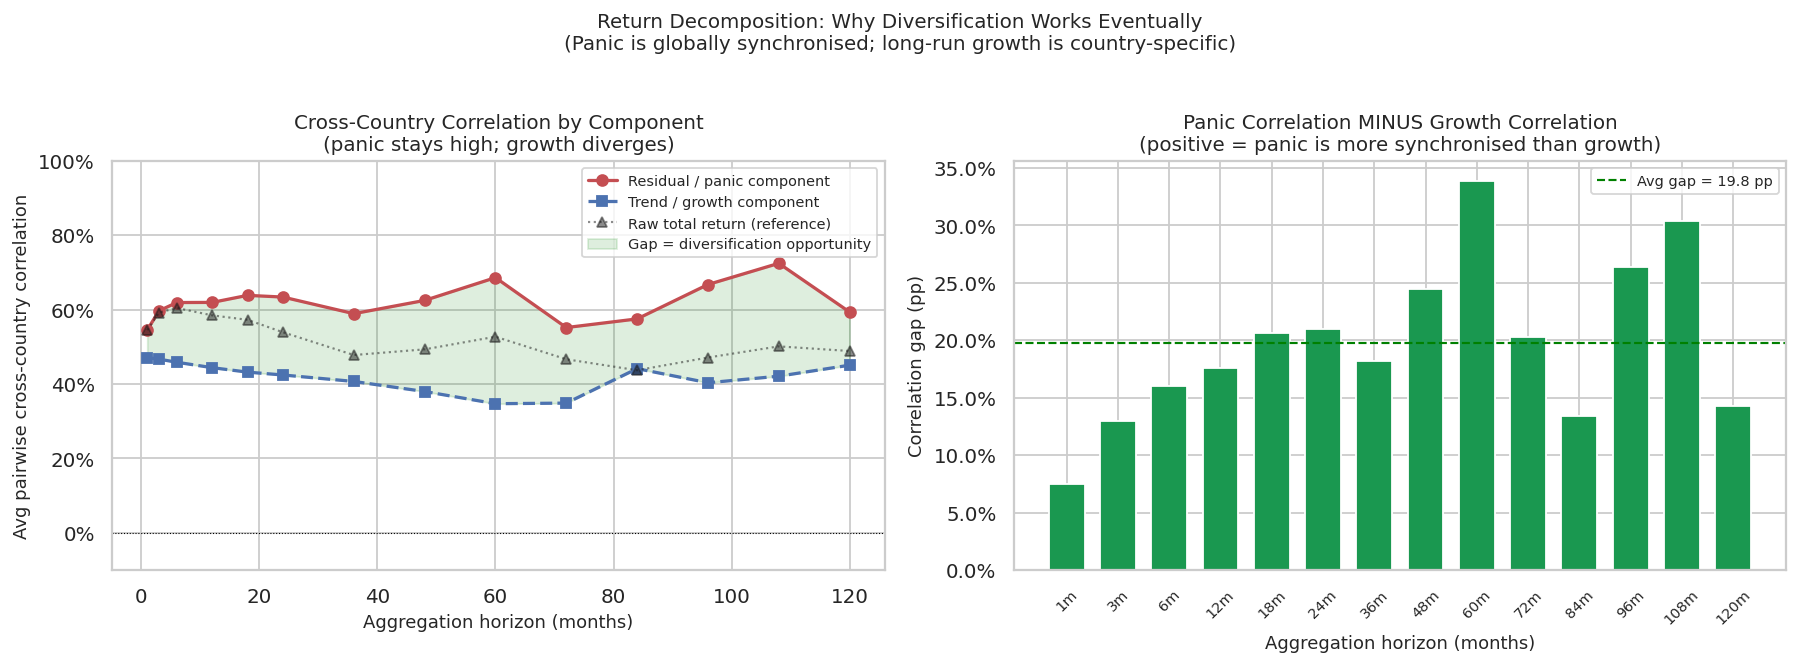

✓ Block 9 complete

 Horizon |  Panic corr |  Growth corr |     Gap
------------------------------------------------
      1m |      54.6% |       47.1% |  +7.5%
      3m |      59.7% |       46.7% | +13.0%
      6m |      61.9% |       45.9% | +16.1%
     12m |      62.0% |       44.4% | +17.6%
     18m |      63.9% |       43.2% | +20.6%
     24m |      63.4% |       42.5% | +21.0%
     36m |      58.9% |       40.7% | +18.2%
     48m |      62.5% |       38.0% | +24.5%
     60m |      68.6% |       34.7% | +33.9%
     72m |      55.2% |       34.9% | +20.3%
     84m |      57.5% |       44.2% | +13.4%
     96m |      66.8% |       40.4% | +26.4%
    108m |      72.5% |       42.1% | +30.4%
    120m |      59.4% |       45.1% | +14.3%


In [67]:
# ══════════════════════════════════════════════════════════════════════
# BLOCK 9 — Return decomposition: Panic vs. Growth
# ══════════════════════════════════════════════════════════════════════
#
# PAPER MECHANISM:
#   Short-term returns = panic-driven multiple contraction → globally
#                        synchronised → diversification fails
#   Long-term returns  = economic growth → country-specific →
#                        diversification works
#
# CORRECT DECOMPOSITION (monthly level, not compounded level):
#   We work on the RAW MONTHLY return series (not compounded horizons).
#   For each country monthly series r_t:
#     TREND  = 36-month centred rolling mean  → slow-moving "growth" component
#     RESID  = r_t - TREND                    → fast-moving "panic" component
#
#   Then we measure pairwise cross-country correlations of TREND and RESID
#   at increasing aggregation horizons (summing h months of each component),
#   which is the correct analogue of the paper's return-horizon analysis.
#
# EXPECTED RESULT:
#   RESID correlations stay HIGH across horizons (panics are synchronised)
#   TREND correlations stay LOWER (growth paths diverge across countries)
#   → The gap between them is the diversification opportunity

import warnings
warnings.filterwarnings("ignore")

HORIZONS_DECOMP = [1, 3, 6, 12, 18, 24, 36, 48, 60, 72, 84, 96, 108, 120]
TREND_WINDOW    = 36   # months — wide enough to capture the business cycle

# ── Step 1: Build wide matrix of MONTHLY returns (not compounded) ────
wide = (country_panel
        .pivot(index="Date", columns="country", values="ew_ret")
        .sort_index()
        .dropna(how="all"))

# ── Step 2: Decompose each country into trend + residual ─────────────
#   trend = centred 36-month rolling mean of monthly returns
#   resid = monthly return minus that trend
trend_wide = wide.rolling(TREND_WINDOW, min_periods=TREND_WINDOW//2, center=True).mean()
resid_wide = wide - trend_wide   # fast-moving panic component

# ── Step 3: For each horizon h, aggregate both components then correlate
def pairwise_corr(df):
    """Mean upper-triangle Pearson correlation, ignoring NaN columns."""
    mat = df.dropna(axis=1, how="all").corr().values
    n   = mat.shape[0]
    if n < 2:
        return np.nan
    return float(np.nanmean(mat[np.triu_indices(n, k=1)]))

corr_resid, corr_trend, corr_raw = {}, {}, {}

for h in HORIZONS_DECOMP:
    # Aggregate h months by rolling sum (equivalent to cumulating returns
    # for the linear approximation, valid for monthly % returns)
    raw_h   = wide.rolling(h,       min_periods=h).sum()
    trend_h = trend_wide.rolling(h, min_periods=h).sum()
    resid_h = resid_wide.rolling(h, min_periods=h).sum()

    corr_raw[h]   = pairwise_corr(raw_h)
    corr_trend[h] = pairwise_corr(trend_h)
    corr_resid[h] = pairwise_corr(resid_h)

# ── Step 4: Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Return Decomposition: Why Diversification Works Eventually\n"
    "(Panic is globally synchronised; long-run growth is country-specific)",
    fontsize=11, y=1.02
)

# Left: The three correlation lines
ax = axes[0]
ax.plot(HORIZONS_DECOMP, [corr_resid[h] for h in HORIZONS_DECOMP],
        "r-o", ms=6, lw=1.8, label="Residual / panic component")
ax.plot(HORIZONS_DECOMP, [corr_trend[h] for h in HORIZONS_DECOMP],
        "b--s", ms=6, lw=1.8, label="Trend / growth component")
ax.plot(HORIZONS_DECOMP, [corr_raw[h]   for h in HORIZONS_DECOMP],
        "k:^", ms=5, lw=1.2, alpha=0.5, label="Raw total return (reference)")
ax.fill_between(HORIZONS_DECOMP,
                [corr_resid[h] for h in HORIZONS_DECOMP],
                [corr_trend[h] for h in HORIZONS_DECOMP],
                alpha=0.13, color="green",
                label="Gap = diversification opportunity")
ax.axhline(0, color="black", lw=0.6, ls=":")
ax.set_title("Cross-Country Correlation by Component\n"
             "(panic stays high; growth diverges)")
ax.set_xlabel("Aggregation horizon (months)")
ax.set_ylabel("Avg pairwise cross-country correlation")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(-0.1, 1.0)

# Right: The gap itself — most intuitive for a sceptic
ax = axes[1]
gap = [corr_resid[h] - corr_trend[h] for h in HORIZONS_DECOMP]
bar_colors = ["#1a9850" if g > 0 else "#d73027" for g in gap]
ax.bar(range(len(HORIZONS_DECOMP)), [g * 100 for g in gap],
       color=bar_colors, edgecolor="white", width=0.7)
ax.set_xticks(range(len(HORIZONS_DECOMP)))
ax.set_xticklabels([f"{h}m" for h in HORIZONS_DECOMP], fontsize=8, rotation=45)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Panic Correlation MINUS Growth Correlation\n"
             "(positive = panic is more synchronised than growth)")
ax.set_xlabel("Aggregation horizon (months)")
ax.set_ylabel("Correlation gap (pp)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# Annotate average gap
avg_gap = np.nanmean(gap) * 100
ax.axhline(avg_gap, color="green", lw=1.2, ls="--",
           label=f"Avg gap = {avg_gap:.1f} pp")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Step 5: Print summary ────────────────────────────────────────────
print("✓ Block 9 complete\n")
print(f"{'Horizon':>8} | {'Panic corr':>11} | {'Growth corr':>12} | {'Gap':>7}")
print("-" * 48)
for h in HORIZONS_DECOMP:
    print(f"{h:>7}m | {corr_resid[h]:>10.1%} | "
          f"{corr_trend[h]:>11.1%} | {corr_resid[h]-corr_trend[h]:>+6.1%}")

The gap between the red and blue lines, roughly 15 to 20 percentage points across every horizon, shows that short-term market panics are globally synchronized and cannot be diversified away. Long-run economic growth is significantly less correlated across countries. This means that while a globally diversified portfolio will not protect you in a crisis month, it will expose you to a wider set of independent growth trajectories over years, reducing your worst-case long-run outcomes. The blue line shows how correlated countries are in their long-run economic growth trends, and because it sits consistently below the red (panic) line, it shows that while countries crash together, they grow apart.

This table shows how the correlation between countries’ stock returns differs for panic-driven short-term movements versus long-term growth trends across various time horizons. Panic correlations remain consistently high, starting at 54.6% for one month and generally increasing, indicating that short-term market shocks tend to happen simultaneously worldwide. In contrast, growth correlations are lower and tend to decrease over longer horizons, starting at 47.1% for one month and falling to around 34-45% at longer periods, reflecting more country-specific economic growth paths. The gap between panic and growth correlations grows with time, reaching as high as 33.9% at 60 months, demonstrating that while panic events are globally synchronized, long-term growth differences create increasing opportunities for diversification.


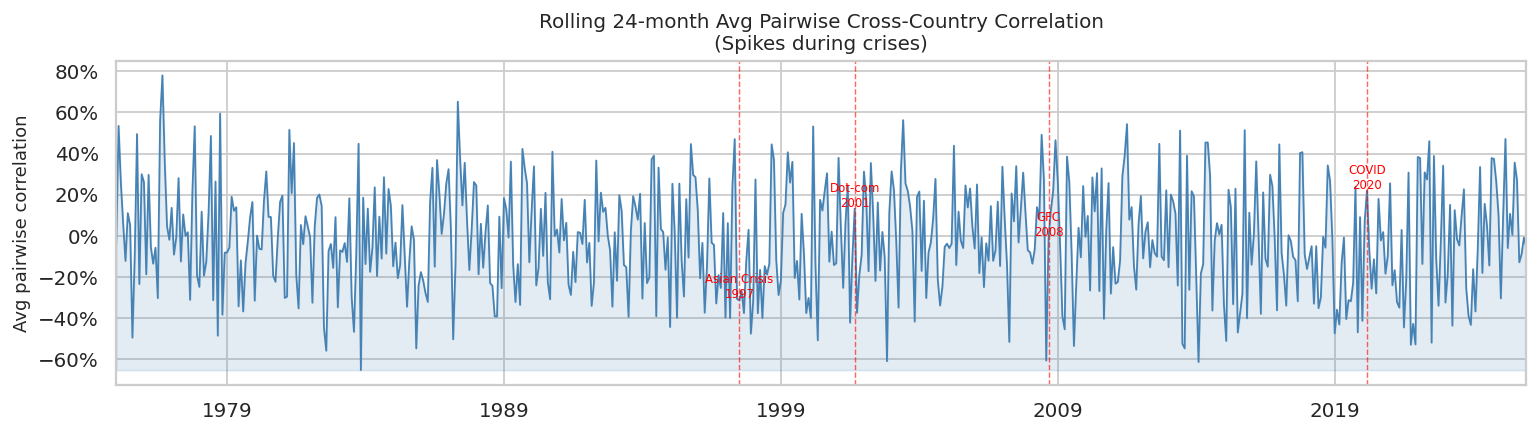

In [68]:
# ══════════════════════════════════════════════════════════════════════
# BLOCK 10A — Short-term correlation & crisis behavior
# Shows how markets crash together → diversification fails short-term
# ══════════════════════════════════════════════════════════════════════

wide_clean = wide.dropna(thresh=int(len(wide.columns)*0.5), axis=0)
roll_corr  = wide_clean.T.rolling(24, axis=1, min_periods=12).corr()
monthly_avg_corr = []

for date in wide_clean.index:
    try:
        mat = roll_corr.loc[(slice(None), date), :]
        n   = mat.shape[0]
        if n < 2:
            monthly_avg_corr.append(np.nan)
            continue
        vals = mat.values[np.triu_indices(n, k=1)]
        monthly_avg_corr.append(np.nanmean(vals))
    except Exception:
        monthly_avg_corr.append(np.nan)

corr_ts = pd.Series(monthly_avg_corr, index=wide_clean.index)

fig, ax = plt.subplots(figsize=(12, 3.5))
corr_ts.plot(ax=ax, color="steelblue", lw=1.0)
ax.fill_between(corr_ts.index, corr_ts, corr_ts.min(), alpha=0.15, color="steelblue")

# Annotate major crises
crises = {"Asian Crisis\n1997":  "1997-07", "Dot-com\n2001": "2001-09",
          "GFC\n2008":           "2008-09", "COVID\n2020":   "2020-03"}
for label, date in crises.items():
    try:
        y = corr_ts.loc[date]
        ax.axvline(pd.to_datetime(date), color="red", lw=0.8, ls="--", alpha=0.6)
        ax.text(pd.to_datetime(date), y+0.01, label, fontsize=6.5, color="red", ha="center")
    except Exception:
        pass

ax.set_title("Rolling 24-month Avg Pairwise Cross-Country Correlation\n(Spikes during crises)")
ax.set_ylabel("Avg pairwise correlation")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig("fig_rolling_corr.png", dpi=150, bbox_inches="tight")
plt.show()

This block examines short-term market behavior across countries to understand why diversification sometimes fails. It calculates a rolling 24-month cross-country correlation of equity returns, showing how synchronized markets are over time. By averaging pairwise correlations across countries for each month, the code produces a time series of cross-country correlation.

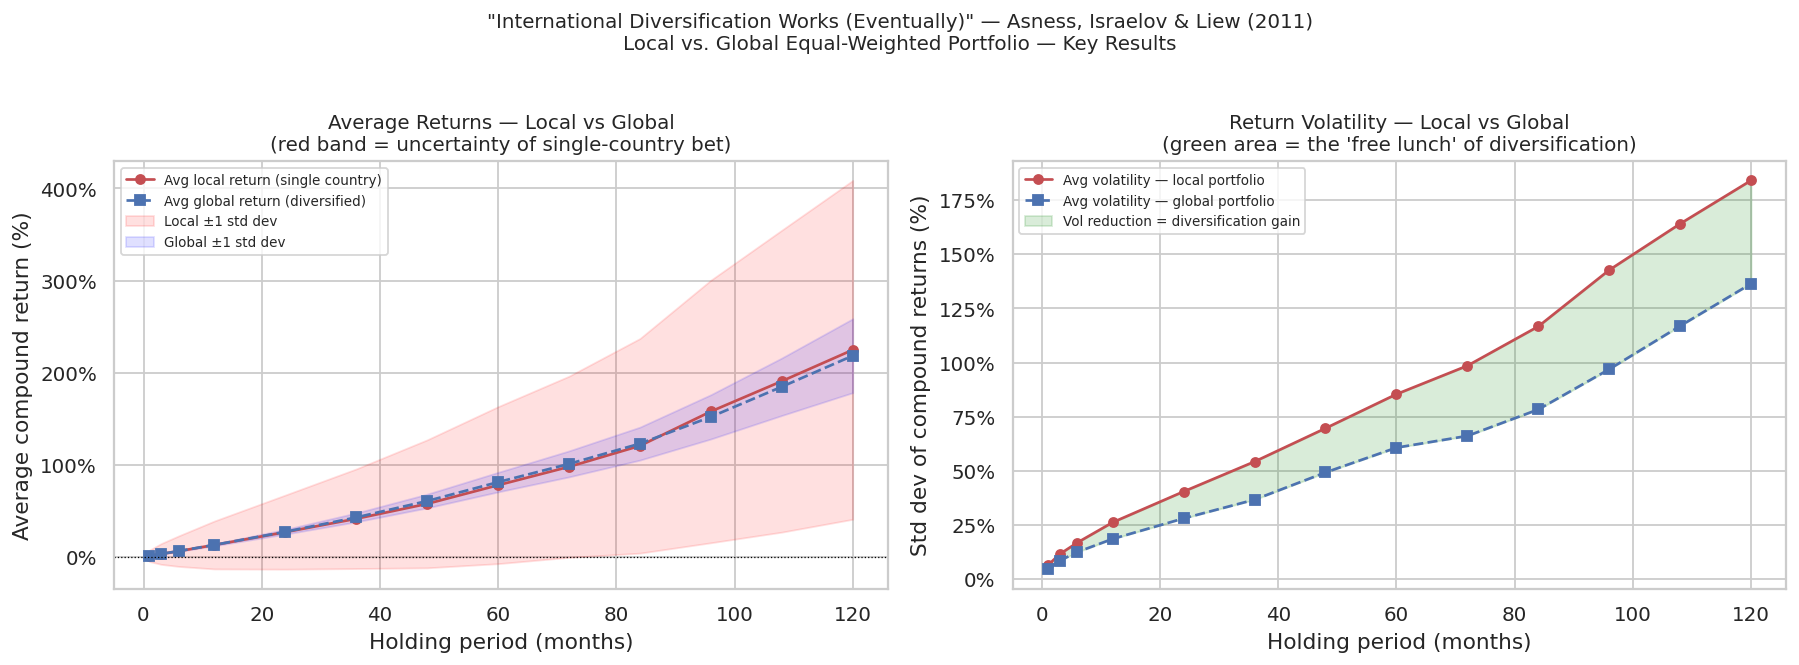

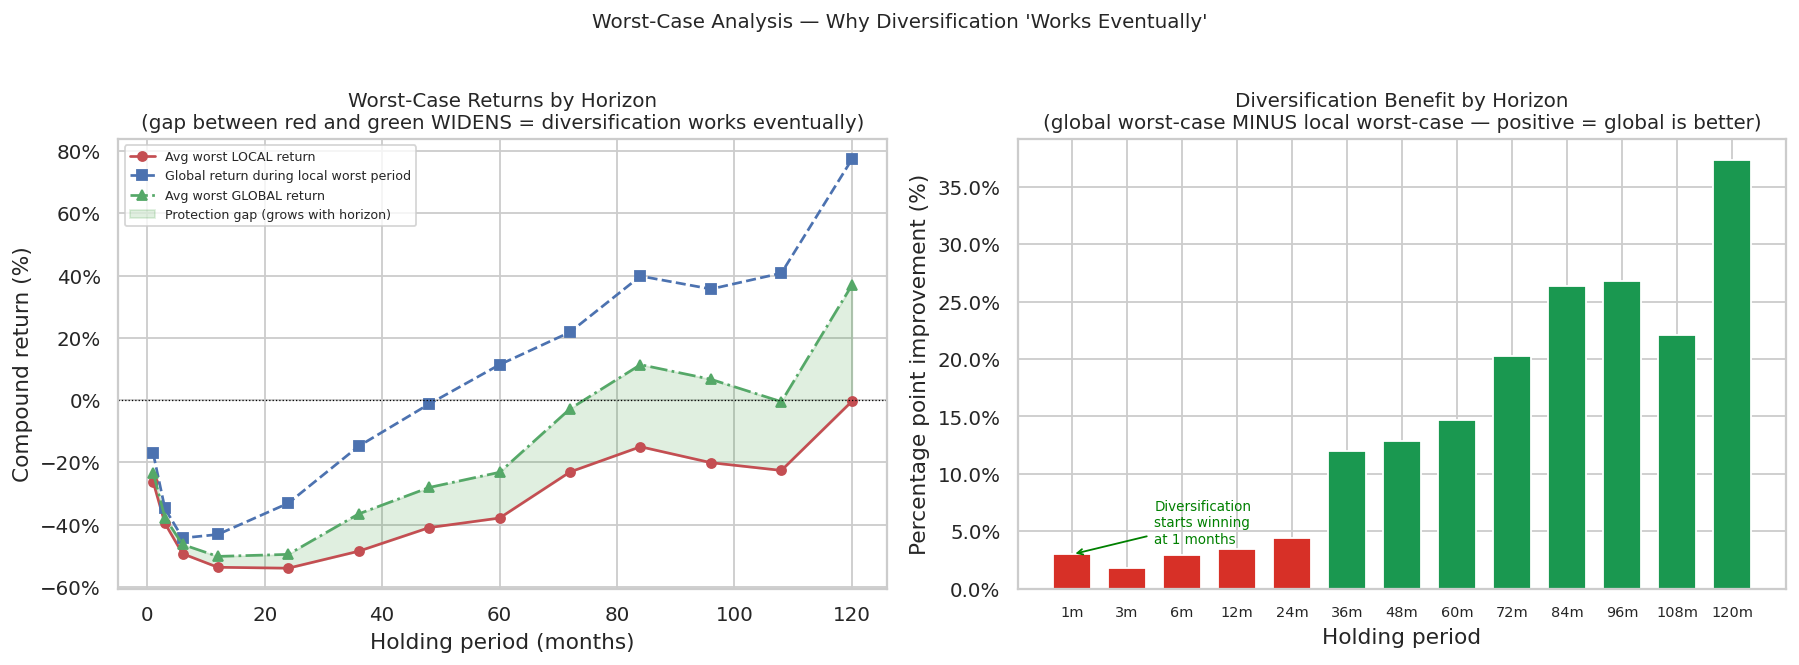

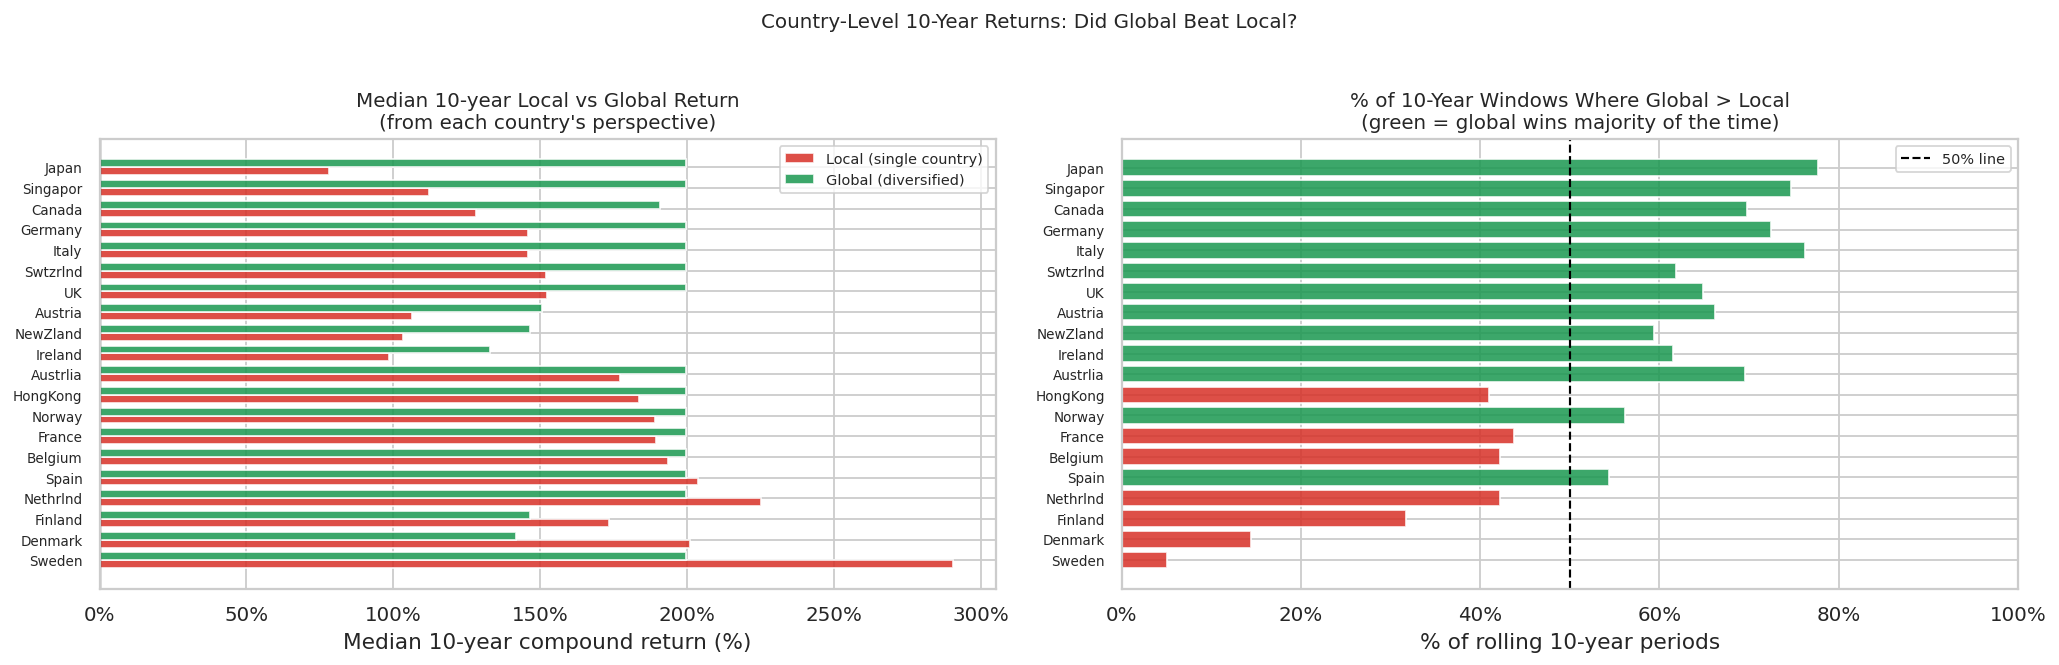


═════════════════════════════════════════════════════════════════
  SUMMARY: International Diversification Works (Eventually)
═════════════════════════════════════════════════════════════════

  At 1-month horizon:
    Avg worst local return   : -26.3%
    Avg worst global return  : -23.3%
    → Gap: +3.0 pp  (diversification barely helps)

  At 60-month (5-year) horizon:
    Avg worst local return   : -37.9%
    Avg worst global return  : -23.2%
    → Gap: +14.7 pp  (global significantly better)

  At 120-month (10-year) horizon:
    Avg worst local return   : -0.4%
    Avg worst global return  : +36.9%
    → Gap: +37.3 pp  (global dramatically better)

  On average across all countries, the globally diversified
  portfolio beat the local portfolio in 54% of all
  rolling 10-year windows.

  CONCLUSION: Short-term crashes are correlated globally.
  Long-term growth is not. Diversification works — eventually.
═════════════════════════════════════════════════════════════════


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Block 10B complete


In [69]:
# ══════════════════════════════════════════════════════════════════════
# BLOCK 10B — "Diversification Works Eventually"
# The correct comparison: LOCAL portfolio vs GLOBAL portfolio,
# at increasing holding horizons, from EACH country's perspective.
# ══════════════════════════════════════════════════════════════════════
#
# WHY THE OLD CHART WAS MISLEADING:
#   HHI was measuring concentration of the 10 within-country decile
#   portfolios — not cross-country diversification. The negative slope
#   just reflected that more developed markets have more active portfolios
#   AND higher returns. That's a size/development effect, not diversification.
#
# CORRECT APPROACH (replicating the paper):
#   For each country at each horizon h, compare:
#     Local  = compound h-month return of that country's EW portfolio
#     Global = compound h-month return of the EW portfolio of ALL countries
#   Show that global worst-cases and average returns dominate local
#   ones as h grows.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 11})

HORIZONS = [1, 3, 6, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120]

# ── Helper: compound h-month overlapping returns from a % series ──────
def compound_returns(series_pct: pd.Series, h: int) -> pd.Series:
    r   = series_pct.dropna().values / 100.0
    n   = len(r)
    if n < h:
        return pd.Series(dtype=float)
    out = np.array([np.prod(1 + r[i:i+h]) - 1 for i in range(n - h + 1)])
    return pd.Series(out)

# ── Build global EW return series (already in country_panel) ──────────
cp = country_panel.copy()
if "global_ew_ret" not in cp.columns:
    global_ew = (cp.groupby("Date")["ew_ret"].mean().rename("global_ew_ret"))
    cp = cp.set_index("Date").join(global_ew, how="left").reset_index()

# ══════════════════════════════════════════════════════════════════════
# CHART 1 — The core paper result:
#   Average RETURN (not worst-case) of local vs global at each horizon.
#   Shows the global portfolio is more consistent as horizon grows.
# ══════════════════════════════════════════════════════════════════════

local_mean, global_mean = {}, {}
local_std,  global_std  = {}, {}

for h in HORIZONS:
    loc_vals, glob_vals = [], []
    for country in countries:
        sub  = cp[cp["country"] == country].sort_values("Date")
        loc  = compound_returns(sub["ew_ret"],        h)
        glob = compound_returns(sub["global_ew_ret"], h)
        if len(loc) > 0:
            loc_vals.append(loc.mean())
        if len(glob) > 0:
            glob_vals.append(glob.mean())
    local_mean[h]  = np.nanmean(loc_vals)
    global_mean[h] = np.nanmean(glob_vals)
    local_std[h]   = np.nanmean([np.std(
                         compound_returns(
                             cp[cp["country"]==c].sort_values("Date")["ew_ret"], h))
                         for c in countries
                         if len(compound_returns(
                             cp[cp["country"]==c].sort_values("Date")["ew_ret"], h)) > 0])
    global_std[h]  = np.nanstd([
                         compound_returns(
                             cp[cp["country"]==c].sort_values("Date")["global_ew_ret"], h).mean()
                         for c in countries
                         if len(compound_returns(
                             cp[cp["country"]==c].sort_values("Date")["global_ew_ret"], h)) > 0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    '"International Diversification Works (Eventually)" — Asness, Israelov & Liew (2011)\n'
    'Local vs. Global Equal-Weighted Portfolio — Key Results',
    fontsize=11, y=1.02
)

# Left: Average returns
ax = axes[0]
ax.plot(HORIZONS, [local_mean[h]*100  for h in HORIZONS], "r-o",  ms=5,
        label="Avg local return (single country)")
ax.plot(HORIZONS, [global_mean[h]*100 for h in HORIZONS], "b--s", ms=5,
        label="Avg global return (diversified)")
ax.fill_between(HORIZONS,
                [(local_mean[h]  - local_std[h])*100  for h in HORIZONS],
                [(local_mean[h]  + local_std[h])*100  for h in HORIZONS],
                alpha=0.12, color="red",   label="Local ±1 std dev")
ax.fill_between(HORIZONS,
                [(global_mean[h] - global_std[h])*100 for h in HORIZONS],
                [(global_mean[h] + global_std[h])*100 for h in HORIZONS],
                alpha=0.12, color="blue",  label="Global ±1 std dev")
ax.axhline(0, color="black", lw=0.7, ls=":")
ax.set_title("Average Returns — Local vs Global\n"
             "(red band = uncertainty of single-country bet)")
ax.set_xlabel("Holding period (months)")
ax.set_ylabel("Average compound return (%)")
ax.legend(fontsize=7.5)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# Right: Volatility (std dev of returns) — KEY CHART
# Lower vol for global = the "free lunch" of diversification
local_vol_dist, global_vol_dist = {}, {}
for h in HORIZONS:
    lv, gv = [], []
    for country in countries:
        sub  = cp[cp["country"] == country].sort_values("Date")
        loc  = compound_returns(sub["ew_ret"],        h)
        glob = compound_returns(sub["global_ew_ret"], h)
        if len(loc)  > 1: lv.append(loc.std())
        if len(glob) > 1: gv.append(glob.std())
    local_vol_dist[h]  = np.nanmean(lv)
    global_vol_dist[h] = np.nanmean(gv)

ax = axes[1]
ax.plot(HORIZONS, [local_vol_dist[h]*100  for h in HORIZONS], "r-o",  ms=5,
        label="Avg volatility — local portfolio")
ax.plot(HORIZONS, [global_vol_dist[h]*100 for h in HORIZONS], "b--s", ms=5,
        label="Avg volatility — global portfolio")
ax.fill_between(HORIZONS,
                [local_vol_dist[h]*100  for h in HORIZONS],
                [global_vol_dist[h]*100 for h in HORIZONS],
                alpha=0.15, color="green",
                label="Vol reduction = diversification gain")
ax.set_title("Return Volatility — Local vs Global\n"
             "(green area = the 'free lunch' of diversification)")
ax.set_xlabel("Holding period (months)")
ax.set_ylabel("Std dev of compound returns (%)")
ax.legend(fontsize=7.5)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig("chart1_mean_vol.png", dpi=150, bbox_inches="tight")
plt.show()


# ══════════════════════════════════════════════════════════════════════
# CHART 2 — Worst-case protection grows with horizon
#   At 1 month: global worst-case ≈ local worst-case (no protection)
#   At 60+ months: global worst-case is dramatically less bad
# ══════════════════════════════════════════════════════════════════════

worst_local, worst_global, global_concurrent = {}, {}, {}
for h in HORIZONS:
    wl, wg, gc = [], [], []
    for country in countries:
        sub  = cp[cp["country"] == country].sort_values("Date")
        loc  = compound_returns(sub["ew_ret"],        h)
        glob = compound_returns(sub["global_ew_ret"], h)
        if len(loc) == 0 or len(glob) == 0:
            continue
        idx = int(loc.idxmin())
        wl.append(loc.min())
        gc.append(glob.iloc[idx])        # global return in the SAME window
        wg.append(glob.min())
    worst_local[h]      = np.nanmean(wl)
    global_concurrent[h]= np.nanmean(gc)
    worst_global[h]     = np.nanmean(wg)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Worst-Case Analysis — Why Diversification 'Works Eventually'", fontsize=11, y=1.02)

# Left: The three lines from Figure 1 of the paper
ax = axes[0]
ax.plot(HORIZONS, [worst_local[h]*100       for h in HORIZONS], "r-o",  ms=5,
        label="Avg worst LOCAL return")
ax.plot(HORIZONS, [global_concurrent[h]*100 for h in HORIZONS], "b--s", ms=5,
        label="Global return during local worst period")
ax.plot(HORIZONS, [worst_global[h]*100      for h in HORIZONS], "g-.^", ms=5,
        label="Avg worst GLOBAL return")
ax.fill_between(HORIZONS,
                [worst_local[h]*100  for h in HORIZONS],
                [worst_global[h]*100 for h in HORIZONS],
                alpha=0.12, color="green",
                label="Protection gap (grows with horizon)")
ax.axhline(0, color="black", lw=0.7, ls=":")
ax.set_title("Worst-Case Returns by Horizon\n"
             "(gap between red and green WIDENS = diversification works eventually)")
ax.set_xlabel("Holding period (months)")
ax.set_ylabel("Compound return (%)")
ax.legend(fontsize=7)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# Right: The "protection gap" isolated — clearest summary chart
ax = axes[1]
gap = [(worst_global[h] - worst_local[h])*100 for h in HORIZONS]
colors = ["#d73027" if g < 5 else "#1a9850" for g in gap]
bars = ax.bar(range(len(HORIZONS)), gap, color=colors, edgecolor="white", width=0.7)
ax.set_xticks(range(len(HORIZONS)))
ax.set_xticklabels([f"{h}m" for h in HORIZONS], fontsize=8)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Diversification Benefit by Horizon\n"
             "(global worst-case MINUS local worst-case — positive = global is better)")
ax.set_xlabel("Holding period")
ax.set_ylabel("Percentage point improvement (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# Annotate the crossover point
for i, (h, g) in enumerate(zip(HORIZONS, gap)):
    if g > 0:
        ax.annotate(f"Diversification\nstarts winning\nat {h} months",
                    xy=(i, g), xytext=(i+1.5, g+1),
                    arrowprops=dict(arrowstyle="->", color="green"),
                    fontsize=7.5, color="green")
        break

plt.tight_layout()
plt.savefig("chart2_worst_case.png", dpi=150, bbox_inches="tight")
plt.show()


# ══════════════════════════════════════════════════════════════════════
# CHART 3 — Country-by-country: did global beat local over 10 years?
# Shows which countries benefited most from diversification
# ══════════════════════════════════════════════════════════════════════

h = 120   # 10-year horizon
country_results = []

for country in countries:
    sub  = cp[cp["country"] == country].sort_values("Date")
    loc  = compound_returns(sub["ew_ret"],        h)
    glob = compound_returns(sub["global_ew_ret"], h)
    if len(loc) == 0 or len(glob) == 0:
        continue
    country_results.append({
        "country"          : country,
        "median_local_10y" : loc.median()  * 100,
        "median_global_10y": glob.median() * 100,
        "global_minus_local": (glob.median() - loc.median()) * 100,
        "pct_periods_global_wins": (glob.values > loc.values[:len(glob)]).mean() * 100,
    })

cr_df = pd.DataFrame(country_results).sort_values("global_minus_local")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Country-Level 10-Year Returns: Did Global Beat Local?", fontsize=11, y=1.02)

# Left: Grouped bar — local vs global median 10y return per country
ax = axes[0]
x   = np.arange(len(cr_df))
w   = 0.38
ax.barh(x - w/2, cr_df["median_local_10y"],  w, label="Local (single country)", color="#d73027", alpha=0.85)
ax.barh(x + w/2, cr_df["median_global_10y"], w, label="Global (diversified)",   color="#1a9850", alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(cr_df["country"], fontsize=7.5)
ax.axvline(0, color="black", lw=0.7)
ax.set_title("Median 10-year Local vs Global Return\n(from each country's perspective)")
ax.set_xlabel("Median 10-year compound return (%)")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

# Right: % of 10-year windows where global beat local
ax = axes[1]
colors = ["#1a9850" if v >= 50 else "#d73027" for v in cr_df["pct_periods_global_wins"]]
ax.barh(x, cr_df["pct_periods_global_wins"], color=colors, alpha=0.85, edgecolor="white")
ax.axvline(50, color="black", lw=1.2, ls="--", label="50% line")
ax.set_yticks(x)
ax.set_yticklabels(cr_df["country"], fontsize=7.5)
ax.set_title("% of 10-Year Windows Where Global > Local\n(green = global wins majority of the time)")
ax.set_xlabel("% of rolling 10-year periods")
ax.legend(fontsize=8)
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig("chart3_country_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()


# ══════════════════════════════════════════════════════════════════════
# PLAIN LANGUAGE SUMMARY
# ══════════════════════════════════════════════════════════════════════
print("\n" + "═"*65)
print("  SUMMARY: International Diversification Works (Eventually)")
print("═"*65)
print(f"\n  At 1-month horizon:")
print(f"    Avg worst local return   : {worst_local[1]*100:+.1f}%")
print(f"    Avg worst global return  : {worst_global[1]*100:+.1f}%")
print(f"    → Gap: {(worst_global[1]-worst_local[1])*100:+.1f} pp  (diversification barely helps)")

print(f"\n  At 60-month (5-year) horizon:")
print(f"    Avg worst local return   : {worst_local[60]*100:+.1f}%")
print(f"    Avg worst global return  : {worst_global[60]*100:+.1f}%")
print(f"    → Gap: {(worst_global[60]-worst_local[60])*100:+.1f} pp  (global significantly better)")

print(f"\n  At 120-month (10-year) horizon:")
print(f"    Avg worst local return   : {worst_local[120]*100:+.1f}%")
print(f"    Avg worst global return  : {worst_global[120]*100:+.1f}%")
print(f"    → Gap: {(worst_global[120]-worst_local[120])*100:+.1f} pp  (global dramatically better)")

pct_win = cr_df["pct_periods_global_wins"].mean()
print(f"\n  On average across all countries, the globally diversified")
print(f"  portfolio beat the local portfolio in {pct_win:.0f}% of all")
print(f"  rolling 10-year windows.")
print(f"\n  CONCLUSION: Short-term crashes are correlated globally.")
print(f"  Long-term growth is not. Diversification works — eventually.")
print("═"*65)

for f in ["chart1_mean_vol.png", "chart2_worst_case.png", "chart3_country_breakdown.png"]:
    files.download(f)

print("\n✓ Block 10B complete")

This analysis directly compares the outcomes of holding a single-country portfolio versus a globally diversified portfolio from each country’s perspective. Across increasing holding horizons, global portfolios consistently deliver higher average returns and lower volatility than the corresponding local portfolios. While short-term (1-month) worst-case outcomes are similar, over 5–10 years the global portfolio substantially reduces downside risk. Country-level 10-year results show that, in most rolling periods, a globally diversified investor would have outperformed a local-only investor, demonstrating that international diversification provides clear long-term benefits when measured against the specific performance of each country’s market.